In [1]:
import numpy as np
import torch.utils.data
from IPython.core import display
from torchvision.transforms.v2 import RandomCrop
from src.data.dataset import SeverstalSteelDefectDataset

dataset = SeverstalSteelDefectDataset(
    images_path="../data/train_images",
    label_csv="../data/train.csv",
    transform=RandomCrop((256, 1000))
)

Image shape: torch.Size([1, 256, 1000]), Class label: tensor([0, 0, 1, 1])


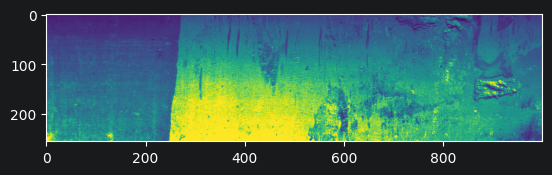

In [2]:
from matplotlib.pyplot import imshow
sample = dataset[5]
imshow(sample[0].permute(1, 2, 0))
print(f"Image shape: {sample[0].shape}, Class label: {sample[1]}")

In [3]:
from src.data.split import stratified_train_test_split

train, val = stratified_train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")

# class distribution of each set
train_labels = [label for _, label in train]
val_labels = [label for _, label in val]

print(f"Train class distribution: {dict(sorted({label: train_labels.count(label) for label in set(train_labels)}.items()))}")
print(f"Validation class distribution: {dict(sorted({label: val_labels.count(label) for label in set(val_labels)}.items()))}")

TypeError: stratified_train_test_split() missing 1 required positional argument: 'labels'

In [ ]:
import numpy as np

print(f"Class distribution: {dict(zip(*np.unique(dataset.targets, return_counts=True)))}")

Image shape: Image([[[255, 255, 255,  ..., 128, 127, 123],
        [255, 255, 255,  ..., 119, 146, 115],
        [255, 255, 255,  ..., 119, 149, 118],
        ...,
        [170, 159, 162,  ..., 133, 120, 123],
        [146, 155, 160,  ..., 148, 141, 148],
        [150, 159, 151,  ...,  97,  87,  93]],

       [[255, 255, 255,  ...,  78,  83,  80],
        [255, 255, 255,  ...,  69,  99,  73],
        [255, 255, 255,  ...,  67, 101,  74],
        ...,
        [168, 157, 160,  ..., 131, 118, 121],
        [144, 153, 158,  ..., 139, 132, 139],
        [148, 157, 149,  ...,  84,  74,  80]],

       [[255, 255, 255,  ...,  67,  74,  71],
        [255, 255, 255,  ...,  58,  89,  61],
        [255, 255, 255,  ...,  54,  89,  61],
        ...,
        [173, 162, 163,  ..., 134, 121, 124],
        [149, 158, 161,  ..., 144, 137, 144],
        [153, 162, 152,  ...,  91,  81,  87]]], dtype=torch.uint8, ), Class label: tensor([1, 0, 0, 0, 0, 0])


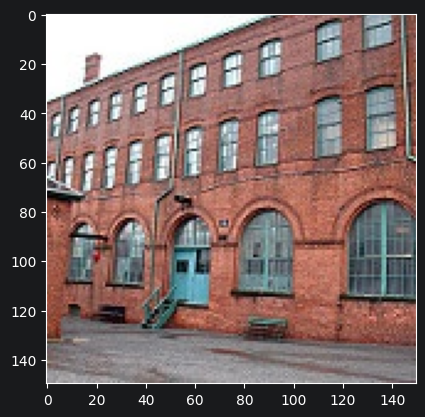

In [14]:
import numpy as np
import torch.utils.data
from torchvision.transforms.v2 import Compose, ToImage, ToDtype
from src.data.dataset import IntelImageClassificationDataset

dataset = IntelImageClassificationDataset(
    images_path="../data/intel/seg_train/seg_train",
    transform=Compose([ToImage()]),
)

from matplotlib.pyplot import imshow
image, target = dataset[5]

print(f"Image shape: {image}, Class label: {target}")
imshow(image.permute(1, 2, 0))